# SeisBench Demo

This notebook is for first-touch exploration only.
We will:

- configure repo-local cache paths for SeisBench and Matplotlib
- list available SeisBench dataset classes
- load one small dataset
- inspect metadata and one waveform sample
- convert that sample into the repository's `WaveformWindow` schema


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from seismo_nn.seisbench import (
    available_seisbench_dataset_names,
    configure_local_seisbench_environment,
    dataset_summary,
    load_seisbench_dataset,
    metadata_preview,
    sample_to_waveform_window,
)

In [3]:
environment = configure_local_seisbench_environment()
environment

SeisBenchEnvironment(cache_root=PosixPath('/Users/brandt/NeuralNetworkDev/.seisbench-cache'), datasets_root=PosixPath('/Users/brandt/NeuralNetworkDev/.seisbench-cache/datasets'), matplotlib_config_dir=PosixPath('/Users/brandt/NeuralNetworkDev/.mplconfig'), xdg_cache_home=PosixPath('/Users/brandt/NeuralNetworkDev/.cache'))

In [4]:
dataset_names = available_seisbench_dataset_names()
pd.Series(dataset_names, name="dataset_name").head(20)

0                      AQ2009Counts
1                          AQ2009GM
2                     BohemiaSaxony
3                              CEED
4                              CREW
5                               CWA
6                          CWANoise
7               ChunkedDummyDataset
8                      DummyDataset
9                              ETHZ
10                           GEOFON
11              ISC_EHB_DepthPhases
12                   InstanceCounts
13                       InstanceGM
14                    InstanceNoise
15                          Iquique
16     LFEStacksCascadiaBostock2015
17         LFEStacksMexicoFrank2014
18    LFEStacksSanAndreasShelly2017
19                            LenDB
Name: dataset_name, dtype: str

## Load a first dataset

`DummyDataset` is a good first stop because it stays small.
You can later switch `DATASET_NAME` to a benchmark such as `ETHZ`, `GEOFON`, or `STEAD`.


In [5]:
DATASET_NAME = "DummyDataset"

dataset = load_seisbench_dataset(
    DATASET_NAME,
    cache="trace",
    metadata_cache=True,
)

dataset_summary(dataset)

2026-04-08 16:21:57,748 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


{'name': 'DummyDataset',
 'n_traces': 100,
 'n_metadata_columns': 24,
 'metadata_columns': ('index',
  'trace_start_time',
  'source_latitude_deg',
  'source_longitude_deg',
  'source_depth_km',
  'source_event_category',
  'source_magnitude',
  'source_magnitude_uncertainty',
  'source_magnitude2',
  'source_magnitude_uncertainty2',
  'trace_name',
  'station_network_code'),
 'component_order': ('Z', 'N', 'E'),
 'split_counts': {'train': 60, 'test': 30, 'dev': 10}}

In [6]:
metadata_preview(dataset)

,index,trace_start_time,source_latitude_deg,source_longitude_deg,source_depth_km,source_event_category,source_magnitude,source_magnitude_uncertainty,source_magnitude2,source_magnitude_uncertainty2,...,station_latitude_deg,station_longitude_deg,station_elevation_m,source_magnitude_type,source_magnitude_type2,split,trace_name_original,trace_chunk,trace_sampling_rate_hz,trace_component_order
0,0,2007/01/01 01:42:45.08,-20.43802,-69.27681,83.18,ID,1.353,0.014,1.426,0.011,...,-21.04323,-69.4874,900.0,MA,ML,train,2007_01_01 01_42_45_08,,20,ZNE
1,1,2007/01/01 02:41:13.75,-21.64059,-68.41443,118.38,ID,1.981,0.020,2.027,0.023,...,-21.04323,-69.4874,900.0,MA,ML,train,2007_01_01 02_41_13_75,,20,ZNE
2,2,2007/01/01 03:50:29.27,-21.84637,-68.53904,111.82,ID,2.719,0.024,2.811,0.026,...,-21.04323,-69.4874,900.0,MA,ML,train,2007_01_01 03_50_29_27,,20,ZNE
3,3,2007/01/01 05:40:02.55,-21.23950,-70.05063,34.95,UP,2.169,0.020,2.269,0.020,...,-21.04323,-69.4874,900.0,MA,ML,train,2007_01_01 05_40_02_55,,20,ZNE
4,4,2007/01/01 05:52:18.43,-21.81511,-68.65773,106.69,ID,2.028,0.021,2.080,0.024,...,-21.04323,-69.4874,900.0,MA,ML,train,2007_01_01 05_52_18_43,,20,ZNE


In [7]:
if "split" in dataset.metadata.columns:
    dataset.metadata["split"].value_counts()
else:
    print("This dataset does not expose a split column.")

In [8]:
sample_index = 0
samples, metadata = dataset.get_sample(sample_index)
samples.shape, metadata["trace_sampling_rate_hz"], metadata.get("trace_component_order")

((3, 1200), 20, 'ZNE')

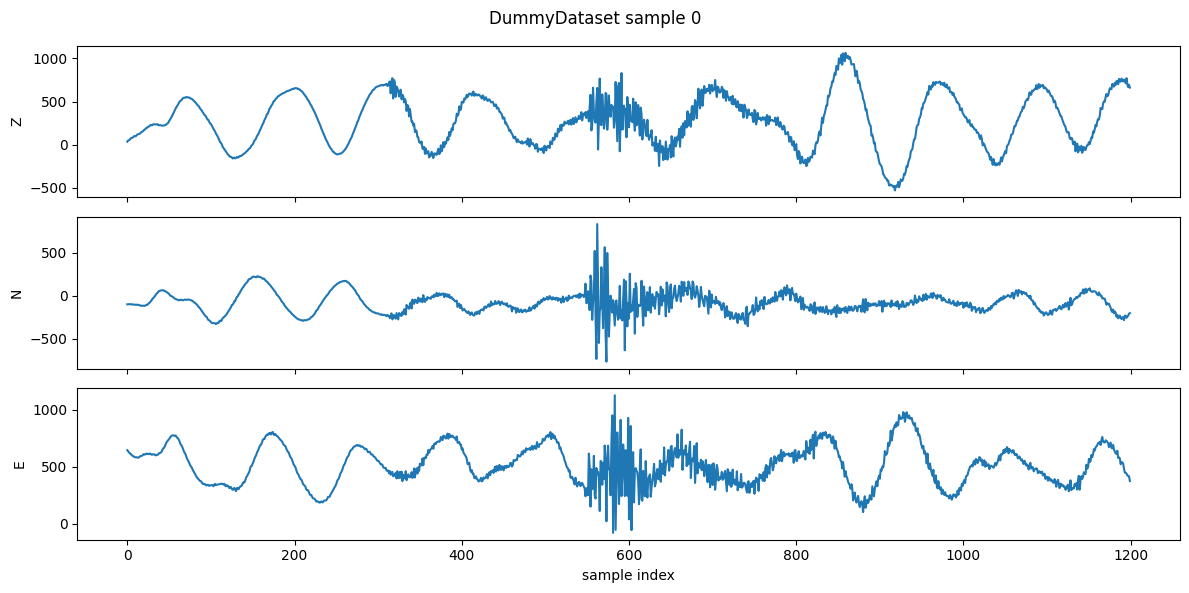

In [9]:
fig, axes = plt.subplots(samples.shape[0], 1, figsize=(12, 6), sharex=True)
time_seconds = range(samples.shape[1])

for axis, component, trace in zip(
    axes, metadata.get("trace_component_order", "ZNE"), samples, strict=True
):
    axis.plot(time_seconds, trace)
    axis.set_ylabel(component)

axes[-1].set_xlabel("sample index")
fig.suptitle(f"{DATASET_NAME} sample {sample_index}")
plt.tight_layout()

In [10]:
window = sample_to_waveform_window(samples, metadata)
window

WaveformWindow(task=<SeismologyTask.PHASE_PICKING: 'phase_picking'>, samples=array([[  34.,   47.,   51., ...,  667.,  695.,  662.],
       [-100.,  -99.,  -98., ..., -229., -208., -201.],
       [ 645.,  636.,  625., ...,  420.,  416.,  374.]], shape=(3, 1200)), sample_rate_hz=20.0, station_code='CX.PB01', event_id='bucket0$0,:3,:1200', channel_order=('Z', 'N', 'E'), metadata={'index': 0, 'trace_start_time': '2007/01/01 01:42:45.08', 'source_latitude_deg': -20.43802, 'source_longitude_deg': -69.27681, 'source_depth_km': 83.18, 'source_event_category': 'ID', 'source_magnitude': 1.353, 'source_magnitude_uncertainty': 0.014, 'source_magnitude2': 1.426, 'source_magnitude_uncertainty2': 0.011, 'trace_name': 'bucket0$0,:3,:1200', 'station_network_code': 'CX', 'station_code': 'PB01', 'station_type': 'BH', 'station_latitude_deg': -21.04323, 'station_longitude_deg': -69.4874, 'station_elevation_m': 900.0, 'source_magnitude_type': 'MA', 'source_magnitude_type2': 'ML', 'split': 'train', 'trace_n

## Next steps

- Filter rows by a metadata field relevant to your first task.
- Inspect P and S arrival columns if you are leaning toward phase picking.
- Decide whether the next reusable step is a dataset adapter, a windowing function, or a baseline task config.
